**Agenda**

To understand all below Supervised Learning algorithms with Description, applications and implemmentation.

Decision Tree

Random Forest

KNN

SVM

Naive Bayes

XGBoost



In [ ]:

from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()



Saving Training.csv to Training.csv


In [ ]:
import pandas as pd

df = pd.read_csv('Training.csv')

df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [ ]:
#EDA
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['prognosis'].value_counts())

(4920, 134)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB
None
           itching    skin_rash  nodal_skin_eruptions  continuous_sneezing  \
count  4920.000000  4920.000000           4920.000000          4920.000000   
mean      0.137805     0.159756              0.021951             0.045122   
std       0.344730     0.366417              0.146539             0.207593   
min       0.000000     0.000000              0.000000             0.000000   
25%       0.000000     0.000000              0.000000             0.000000   
50%       0.000000     0.000000              0.000000             0.000000   
75%       0.000000     0.000000              0.000000             0.000000   
max       1.000000     1.000000              1.000000             1.000000   

         shivering       chills   joint_pain  stomach_pain      acidity  \
count  4920.000000  4

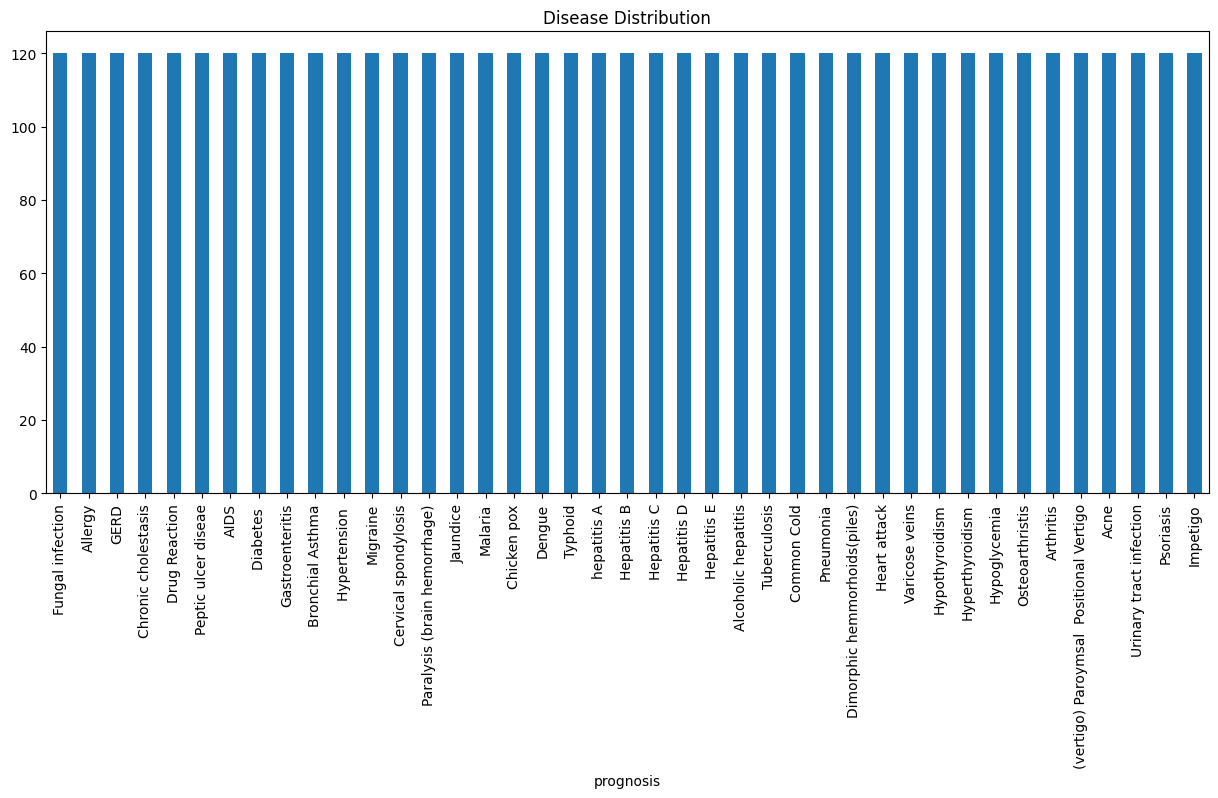

In [ ]:
# Class Distribution
import matplotlib.pyplot as plt

df['prognosis'].value_counts().plot(
    kind='bar',
    figsize=(15,6)
)
plt.title('Disease Distribution')
plt.show()

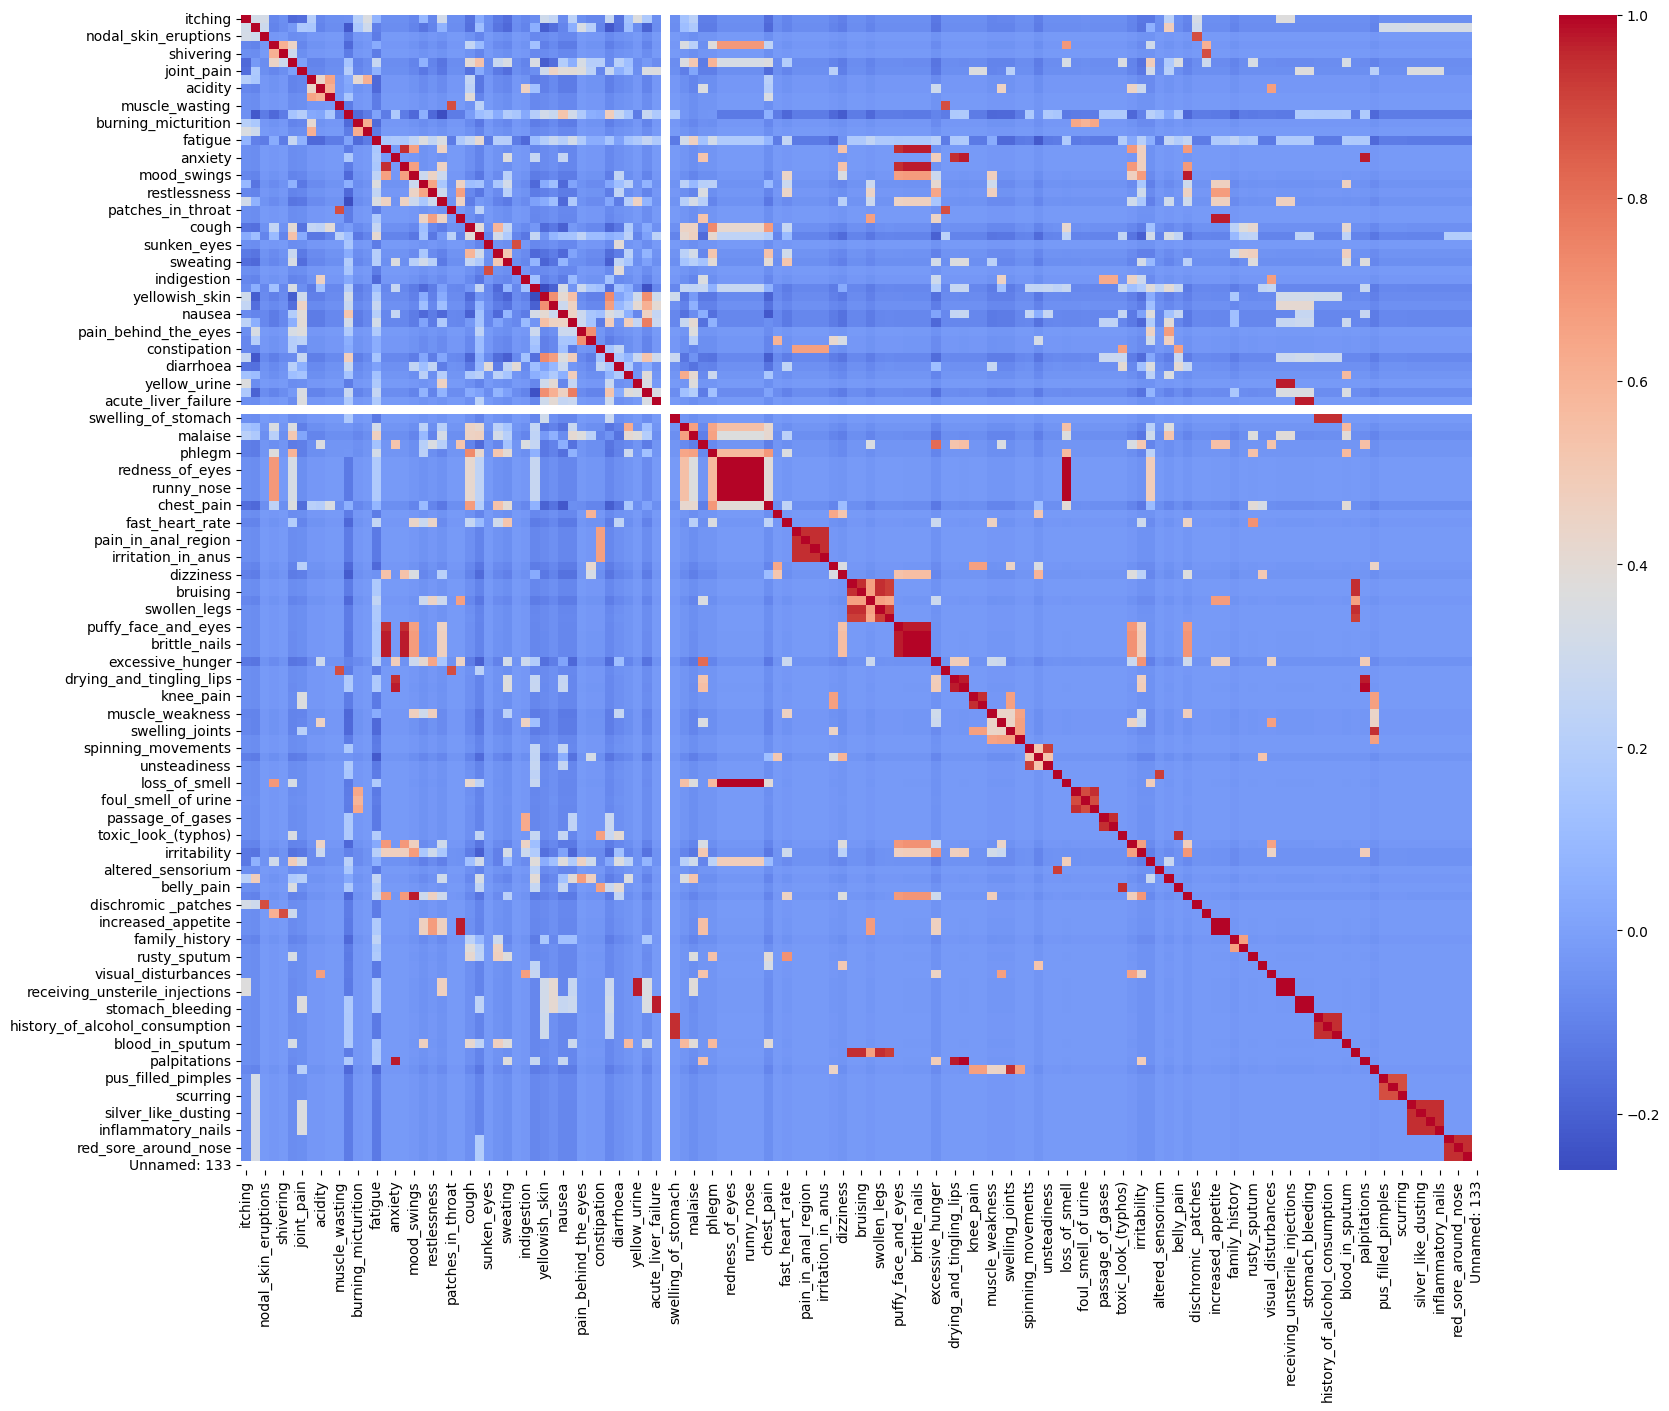

In [ ]:
#Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
sns.heatmap(
    df.drop('prognosis', axis=1).corr(),
    cmap='coolwarm'
)
plt.show()

In [ ]:
#Feature and Target
X = df.drop('prognosis', axis=1)
y = df['prognosis']

In [ ]:
#Encode target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
#Train and split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
#Common Evaluation Function
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(model):

    pred = model.predict(X_test_scaled)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(
        y_test,
        pred,
        average='weighted'
    ))
    print("Recall :", recall_score(
        y_test,
        pred,
        average='weighted'
    ))
    print("F1 Score:", f1_score(
        y_test,
        pred,
        average='weighted'
    ))

    sns.heatmap(
        confusion_matrix(y_test, pred),
        cmap='Blues'
    )
    plt.show()

# Decision Tree

A Decision Tree is a flowchart-like structure where each internal node represents a feature (or attribute), each branch represents a decision rule, and each leaf node represents an outcome. It splits the data into subsets based on the feature values.

Strengths:

Easy to interpret and visualize.

Handles both numerical and categorical data.

Requires little data preprocessing (no need for scaling).

Weaknesses:

Prone to overfitting, especially with complex trees.

Sensitive to noisy data.

Applications:

Used in classification (e.g., customer segmentation) and regression tasks (e.g., predicting house prices).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

Accuracy: 1.0


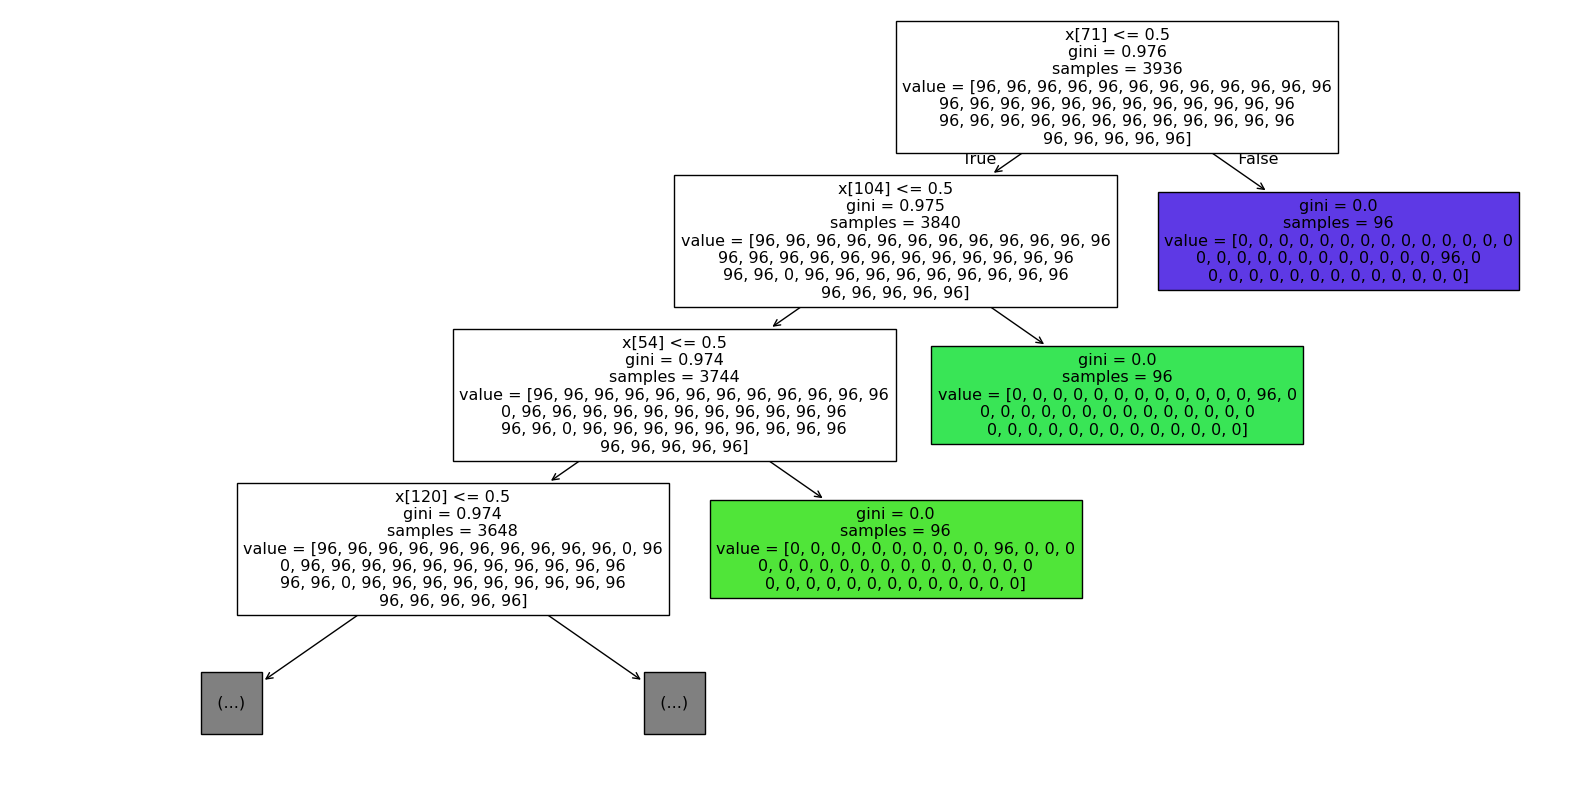

In [ ]:
# Tree Plot
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    max_depth=3
)

plt.show()

# Random ForestDescription:  

Random Forest is an ensemble method that uses multiple Decision Trees to improve model performance. It creates a "forest" of trees by using bootstrapping (sampling with replacement) and random feature selection.

Strengths:

Reduces overfitting compared to a single decision tree.

Handles large datasets with higher dimensionality well.

Provides feature importance scores.

Weaknesses:

Can be less interpretable than a single Decision Tree.

Requires more computational resources and time for training.

Applications:  


Used in various domains, such as finance for credit scoring and healthcare for disease prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

Accuracy: 1.0


# K-Nearest Neighbors (KNN)Description:  

KNN is a simple, instance-based learning algorithm where the model predicts the output for a new instance based on the majority class (for classification) or average (for regression) of its K nearest neighbors in the feature space.

Strengths:

Simple and intuitive; easy to implement.

Naturally handles multi-class classification.

Weaknesses:

Computationally expensive during prediction, especially with large datasets.

Performance is sensitive to the choice of K and distance metric.

Applications:  

Commonly used in recommendation systems, image recognition, and anomaly detection.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

evaluate_model(knn)

ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Support Vector Machine (SVM)Description:  

SVM is a supervised learning algorithm that aims to find the hyperplane that best separates data points of different classes in a high-dimensional space. It can use kernel functions to handle non-linear boundaries.

Strengths:

Effective in high-dimensional spaces.

Works well for clear margin separation.

Weaknesses:

Memory-intensive and can be slow with large datasets.

Requires careful tuning of parameters and kernel choice.

Applications:  

Used in text classification, image classification, and bioinformatics.

In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(
    X_train_scaled,
    y_train
)

evaluate_model(svm)

# Naive BayesDescription:  

Naive Bayes is a family of probabilistic algorithms based on Bayes' Theorem, assuming independence among predictors. It calculates the probability of each class based on the input features.

Strengths:

Simple and efficient, especially for large datasets.

Works well with categorical data and text classification.

Weaknesses:

The independence assumption may not hold in practice, leading to suboptimal performance.

Less effective for datasets with highly correlated features.

Applications:  

Widely used in spam detection, sentiment analysis, and text classification.


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(
    X_train_scaled,
    y_train
)

evaluate_model(nb)